## Section 3.3 CLIP Interpretability


In [2]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import os

# Computes CLIP embeddings for all images in a directory and returns them in a dictionary with filenames as keys
def compute_clip_embeddings(image_dir, device='cuda' if torch.cuda.is_available() else 'cpu'):
    # Load CLIP model and processor
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    embeddings = {}

    for filename in sorted(os.listdir(image_dir)):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            image_path = os.path.join(image_dir, filename)
            image = Image.open(image_path).convert("RGB")

            inputs = processor(images=image, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model.get_image_features(**inputs)
                normalized = outputs / outputs.norm(p=2, dim=-1, keepdim=True)
                embeddings[filename] = normalized.cpu().tolist()

    return embeddings

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3.3.1 Temporal Similarity Curve

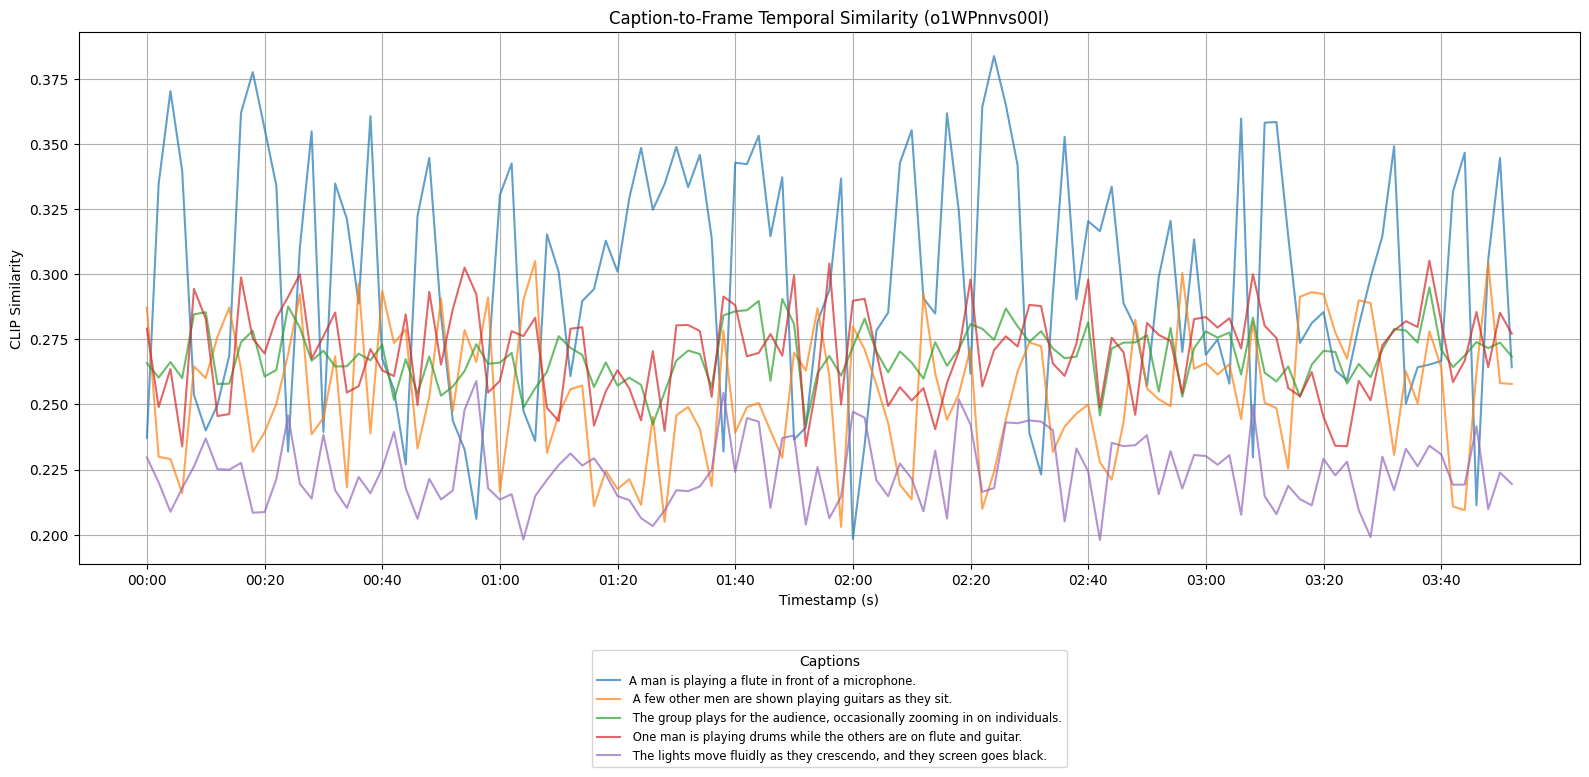

In [17]:
import os
import json
from datasets import load_dataset
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def format_mmss(x, pos):
    minutes = int(x // 60)
    seconds = int(x % 60)
    return f"{minutes:02}:{seconds:02}"

# Load the dataset, trust_remote_code=True is needed to load the dataset from the remote repository.
# This is where we get our captions from.
dataset = load_dataset('dataset-download.py', trust_remote_code=True) 

# Load the CLIP Model and Processor for embedding the image and text fields
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load captions and video metadata
with open("top10.json", "r") as data_file:
    video_metadata = json.load(data_file)

# Directory containing the extracted keyframes
keyframes_dir = "keyframes"
video_chosen = "o1WPnnvs00I"

video_keyframes_dir = os.path.join(keyframes_dir, video_chosen)
frame_files = sorted(os.listdir(video_keyframes_dir))
frame_timestamps = [i * 2 for i in range(len(frame_files))]  # i * 2 because we extract a frame every 2 seconds
frame_embeddings = compute_clip_embeddings(image_dir = f"{keyframes_dir}/{video_chosen}")
frame_embs = [frame_embeddings[frame] for frame in frame_files if frame in frame_embeddings]

# Iterate over each video in the dataset and select the metadata for the chosen video only
video_info = {}
for split in ['train', 'test', 'validation']:
    for video in dataset[split]:
        if video['video_id'] == "v_" + video_chosen:
            # Iterate through the documents in doc_list
            video_info[video_chosen] = {
                "video_id": video['video_id'],
                "url": video['video_path'],
                "duration": video['duration'],
                "captions_starts": video['captions_starts'],
                "captions_ends": video['captions_ends'],
                "captions": video['en_captions'],
            }

# Generate caption embeddings
inputs = processor(text= video_info[video_chosen]['captions'], return_tensors= "pt", padding= True).to(device)
caption_embeddings = model.get_text_features(**inputs)
caption_embeddings = caption_embeddings / caption_embeddings.norm(dim= -1, keepdim= True)
caption_embeddings = caption_embeddings.detach().cpu().tolist()

# Compute Similarity
similarity_curves = []
for caption_embedding in caption_embeddings:
    sims = [np.dot(caption_embedding, frame_emb[0]) for frame_emb in frame_embs]
    similarity_curves.append(sims)
    
# Plot the similarity curves
plt.figure(figsize=(16, 8))
for i, sims in enumerate(similarity_curves):
    plt.plot(frame_timestamps, sims, label=f"{video_info[video_chosen]['captions'][i]}", alpha=0.7)
    
plt.xlabel("Timestamp (s)")
plt.ylabel("CLIP Similarity")
plt.title("Caption-to-Frame Temporal Similarity (o1WPnnvs00I)")
plt.grid(True)
# Legend outside
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol = 1,
    title="Captions",
    fontsize="small"
)
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_mmss))
# Determine the max time
max_time = frame_timestamps[-1]

# Generate ticks every 20 seconds
custom_ticks = np.arange(0, max_time + 1, 20)

# Apply them
plt.xticks(ticks=custom_ticks)
plt.tight_layout()
plt.show()

# 3.3.1 Interpretable Visual Maps

C:\Users\rafae\AppData\Local\Temp\ipykernel_16836\1979047396.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  similarity_matrix[i, j] = sim


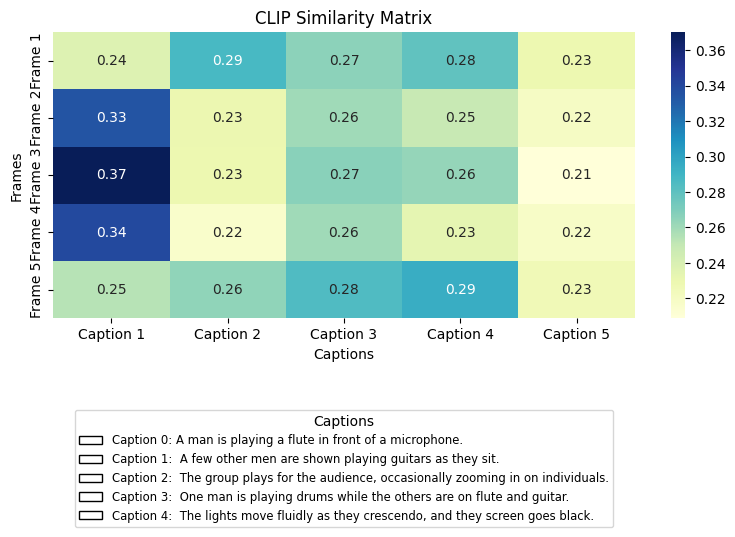

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

N = len(caption_embeddings)

# Compute similarity matrix
similarity_matrix = np.zeros((N, N))
for i in range(N):  # frame index
    for j in range(N):  # caption index
        sim = np.dot(frame_embeddings[i], caption_embeddings[j])
        similarity_matrix[i, j] = sim

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=[f"Caption {i+1}" for i in range(N)],
            yticklabels=[f"Frame {i+1}" for i in range(N)])
plt.title("CLIP Similarity Matrix")
plt.xlabel("Captions")
plt.ylabel("Frames")

legend_elements = [
    Patch(facecolor='white', edgecolor='black', label=f"Caption {i}: {video_info[video_chosen]['captions'][i]}")
    for i in range(len(video_info[video_chosen]['captions']))
]

plt.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.3),
    frameon=True,
    fontsize='small',
    title='Captions',
    ncol=1
)


plt.tight_layout()
plt.show()
